# Mobile Mapping – Lab 2
**Coordinate Frames & Transformations** (Template – _no solutions_)


This notebook guides you through **Lab 2** of the *Mobile Mapping* course  
and provides structured placeholders for **all tasks**.

* tasks translated to **English**  
* mini‑theory reminders with formulae wrapped in `$$ … $$`  
* hints on helpful functions (`numpy`, `scipy`, `open3d`)  
* starter code that follows **PEP 8** (snake_case)  

> **Important:** Only add your own code/answers in the **TODO** cells.


A homogeneous transform is written as  

$$
T = \begin{pmatrix}
R & \mathbf t \\[4pt]
\mathbf 0^{\!\top} & 1
\end{pmatrix},
\qquad
R \in \mathrm{SO}(3),\; \mathbf t\in\mathbb R^3.
$$

It acts on a point in homogeneous coordinates $\tilde{\mathbf x}$ via  

$$
\tilde{\mathbf x}_{\text{new}} = T\,\tilde{\mathbf x}_{\text{old}}.
$$

* **Rotation** $$R$$ preserves lengths and angles ($R^\top R = I,\; \det R = +1$).  
* **Translation** $$\mathbf t$$ shifts the origin.

_Composing_ two transforms is just matrix multiplication:

$$
T_{AC} = T_{BC}\,T_{AB}.
$$


## 1  Working with Coordinate Transformations

In [70]:
%matplotlib widget

from pathlib import Path

import numpy as np
from scipy.spatial import transform as tf
from matplotlib import pyplot as plt
import pytransform3d as pt3d
from pytransform3d import camera

data_dir = (Path.cwd().parent / ".data").resolve()
assert data_dir.exists(), data_dir


### Task 1.1  Define Orientation

* Use Euler angles `angles = [0, 0, 0]` (roll–pitch–yaw).  
* Create the rotation matrix:
* Convert it to a **homogeneous** transform  
* Set a translation vector `t = [0, 0, 0]`.  
* Convert it to a homogeneous transform  
* Print `T`.


In [71]:
rpy = [0, 0, 0]  # roll, pitch, yaw in radians
tau = [0, 0, 0]  # translation in meters

R = tf.Rotation.from_euler(seq="xyz", angles=rpy, degrees=False)
R_mat = tf.Rotation.from_euler(seq="xyz", angles=rpy, degrees=False).as_matrix()
assert np.allclose(R_mat, np.eye(3)), "All angles should be zero!"
assert np.allclose(R_mat.T @ R_mat, np.eye(3)), "Rotation matrix is not orthogonal!"
print(f"Rotation matrix:\n{R_mat}")

R_mat_h = np.eye(4)
R_mat_h[:3, :3] = R_mat
print(f"Homogeneous rotation matrix:\n{R_mat_h}")

T_mat_h = np.eye(4)
T_mat_h[:3, 3] = tau
assert np.allclose(
    tf.RigidTransform.from_translation(tau).as_matrix(), T_mat_h
), "Translation matrix is not correct!"
print(f"Homogenous translation matrix:\n{T_mat_h}")

T = np.eye(4)
T[:3, :3] = R_mat
T[:3, 3] = np.array(tau).reshape(3)

assert np.allclose(
    T, R_mat_h @ T_mat_h
), "Homogeneous transform is not the product of rotation and translation!"
T_alt = tf.RigidTransform.from_components(rotation=R, translation=tau).as_matrix()
assert np.allclose(
    T_alt, T
), f"Homogeneous transform is not correct: \n''{T}''\n``{T_alt}``"
print(f"Homogeneous transformation matrix:\n{T}")

Rotation matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Homogeneous rotation matrix:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
Homogenous translation matrix:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
Homogeneous transformation matrix:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


Second view: 
[[ 0.  0.  1.  0.]
 [ 0.  1.  0.  0.]
 [-1.  0.  0.  5.]
 [ 0.  0.  0.  1.]]
Third view: 
[[ 0. -0. -1.  5.]
 [ 0.  1. -0.  0.]
 [ 1.  0.  0.  0.]
 [ 0.  0.  0.  1.]]


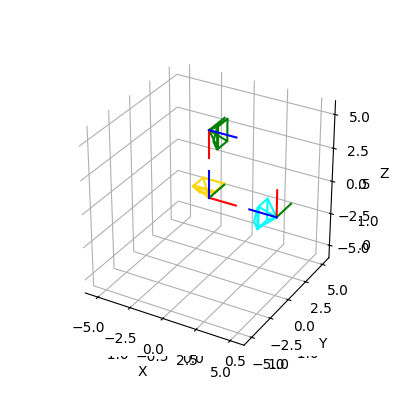

In [72]:
w, h = 640*3, 480*3  # 4:3 aspect
f = 1200  # focal length in pixels

K = np.array(
    [
        [f, 0, w / 2],
        [0, f, h / 2],
        [0, 0, 1],
    ]
)


# second camera: p=90°, tz=5m
T2 = tf.RigidTransform.from_components(
    translation=[0, 0, 5],
    rotation=tf.Rotation.from_euler(seq="xyz", angles=[0, 90, 0], degrees=True),
).as_matrix()
print(f"Second view: \n{T2.round(2)}")

# third view: p=-90°, tx=5m
T3 = tf.RigidTransform.from_components(
    translation=[5, 0, 0],
    rotation=tf.Rotation.from_euler(seq="xyz", angles=[0, -90, 0], degrees=True),
).as_matrix()
print(f"Third view: \n{T3.round(2)}")

ax_s = 20
camera.plot_camera(cam2world=T, M=K, sensor_size=(w, h), ax_s=ax_s, c="gold")
ax = plt.gca()
pt3d.plot_utils.Frame(A2B=T, s=ax_s / 10).add_frame(ax)

camera.plot_camera(cam2world=T2, M=K, sensor_size=(w, h), ax_s=ax_s, c="green")
pt3d.plot_utils.Frame(A2B=T2, s=ax_s / 10).add_frame(ax)

camera.plot_camera(cam2world=T3, M=K, sensor_size=(w, h), ax_s=ax_s, c="cyan")
pt3d.plot_utils.Frame(A2B=T3, s=ax_s / 10).add_frame(ax)

lim = [-6, 6]
for axis in "xyz":
    getattr(ax, f"set_{axis}lim")(lim)
# Red: x, Green: y, Blue: z
plt.show()

In [73]:
# from K2 to K3: T23 = T13 @ T21 = T3 @ T12^(-1)

T23 = T3 @ np.linalg.inv(T2)
print(f"T23 (Camera 2 to Camera 3):\n{T23.round(3)}")

R23 = tf.Rotation.from_matrix(T23[:3, :3]).as_euler(seq="xyz", degrees=True)
print(f"R23 (rpy in deg): {R23.round(1)}")
print(f"t23 (in m): {T23[:3, 3].round(2)}")

T23 (Camera 2 to Camera 3):
[[-1.  0. -0.  5.]
 [ 0.  1.  0.  0.]
 [ 0.  0. -1.  5.]
 [ 0.  0.  0.  1.]]
R23 (rpy in deg): [180.  -0. 180.]
t23 (in m): [5. 0. 5.]


## 2  RPY Representation

$$
R = R_z(\psi)\, R_y(\theta)\, R_x(\phi),
$$

where  

* **roll** $\phi$ – rotation about $x$  
* **pitch** $\theta$ – rotation about $y'$  
* **yaw** $\psi$ – rotation about $z''$


In [74]:
def set_rpy(rpy) -> np.ndarray:
    """Create a 3x3 rotation matrix from (roll, pitch, yaw).
    Args:
        rpy: Roll, pitch, yaw angles in radians (list or np.ndarray).
    Returns:
        3x3 rotation matrix.
    """
    rpy = np.asarray(rpy)
    roll, pitch, yaw = rpy
    Rphi = np.array([
        [1, 0, 0],
        [0, np.cos(roll), -np.sin(roll)],
        [0, np.sin(roll), np.cos(roll)],
    ])
    Rtheta = np.array([
        [np.cos(pitch), 0, np.sin(pitch)],
        [0, 1, 0],
        [-np.sin(pitch), 0, np.cos(pitch)],
    ])
    Rpsi = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw), np.cos(yaw), 0],
        [0, 0, 1],
    ])
    return Rpsi @ Rtheta @ Rphi

def get_rpy(R_mat: np.ndarray) -> np.ndarray:
    """Extract (roll, pitch, yaw) from a 3x3 matrix."""
    assert R_mat.shape == (3, 3), "Input must be a 3x3 matrix."

    pitch = np.arcsin(-R_mat[2, 0])
    if np.abs(np.cos(pitch)) < 1e-6:
        # Gimbal lock
        roll = 0
        yaw = np.arctan2(-R_mat[0, 1], R_mat[1, 1])
    else:
        roll = np.arctan2(R_mat[2, 1], R_mat[2, 2])
        yaw = np.arctan2(R_mat[1, 0], R_mat[0, 0])
    return np.array([roll, pitch, yaw])

## 3  Check if Rotation

In [75]:
def is_rot(R_mat: np.ndarray) -> bool:
    """Check if a matrix is a valid rotation matrix."""
    return np.allclose(R_mat.T @ R_mat, np.eye(3), rtol=1e-3) and np.isclose(np.linalg.det(R_mat), 1.0, rtol=1e-3)

# Verification
assert is_rot(T2[:3, :3]), "T2 is not a valid rotation matrix!"
assert is_rot(T3[:3, :3]), "T3 is not a valid rotation"
assert is_rot(T23[:3, :3]), "T23 is not a valid rotation matrix!"

In [76]:
R = set_rpy((np.random.rand(3) * 10 - 5).tolist())

print(np.linalg.det(R))
print(R.T @ R)

1.0
[[1.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.00000000e+00 9.67786976e-18]
 [0.00000000e+00 9.67786976e-18 1.00000000e+00]]


## 4  Transforming Point Clouds

In [77]:
import open3d as o3d

pth = data_dir / "LV_2" / "teapotOut.ply"
assert pth.exists(), pth

pc = o3d.io.read_point_cloud(str(pth))
print(pc)

PointCloud with 41472 points.


In [78]:
M = np.array(
    [
        [np.cos(np.pi/4), np.sin(np.pi/4), 0, 0],
        [-np.sin(np.pi/4), np.cos(np.pi/4), 0, 0],
        [0, 0, 1, 5],
        [0, 0, 0, 1]
    ]
)

assert is_rot(M[:3, :3])
get_rpy(M[:3, :3])

array([ 0.        , -0.        , -0.78539816])

In [82]:
pc2 = pc.transform(M)

o3d.visualization.draw_geometries([pc + pc2])

In [81]:
pc + pc2

PointCloud with 82944 points.

In [103]:
# iterate through points; tf each point using M
def tf_point(p, M: np.ndarray) -> np.ndarray:
    return (M @ np.append(p, 1))[:3]

def tf_point_cloud(pc: o3d.geometry.PointCloud, M: np.ndarray) -> o3d.geometry.PointCloud:
    # M is 4x4
    X = np.asarray(pc.points)                   # (N, 3)
    Xh = np.hstack([X, np.ones((X.shape[0], 1))])   # (N, 4)
    Xt = (Xh @ M.T)[:, :3]                     # (N, 3)

    pc_new = o3d.geometry.PointCloud()
    pc_new.points = o3d.utility.Vector3dVector(Xt)
    return pc_new

In [104]:
pc_new = tf_point_cloud(pc, M)
pc_new

PointCloud with 41472 points.

In [105]:
o3d.visualization.draw_geometries([pc + pc_new])

![pcd](../figures/lv2_pcs.png)